# Code Lab 4. Keras Optimization 

Для выполнения этого задания нужно будет дописать код в этом ноутбуке  

В этом упражнении Вам предстоит:

- найти лучшие гиперпараметры **learning rate и regularization** 
- **визуализировать** матрицу оптимальных весов.

In [18]:
import time
import random
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

%matplotlib inline
plt.rcParams['figure.figsize'] = (16.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'

# Загрузка датасета CIFAR-10 и предварительная подготовка

In [19]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Проверим размер входных и выходных векторов.
print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)
print()

/home/andrej/miniconda3/lib/python3.13/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Training data shape:  (50000, 32, 32, 3)
Training labels shape:  (50000, 1)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000, 1)



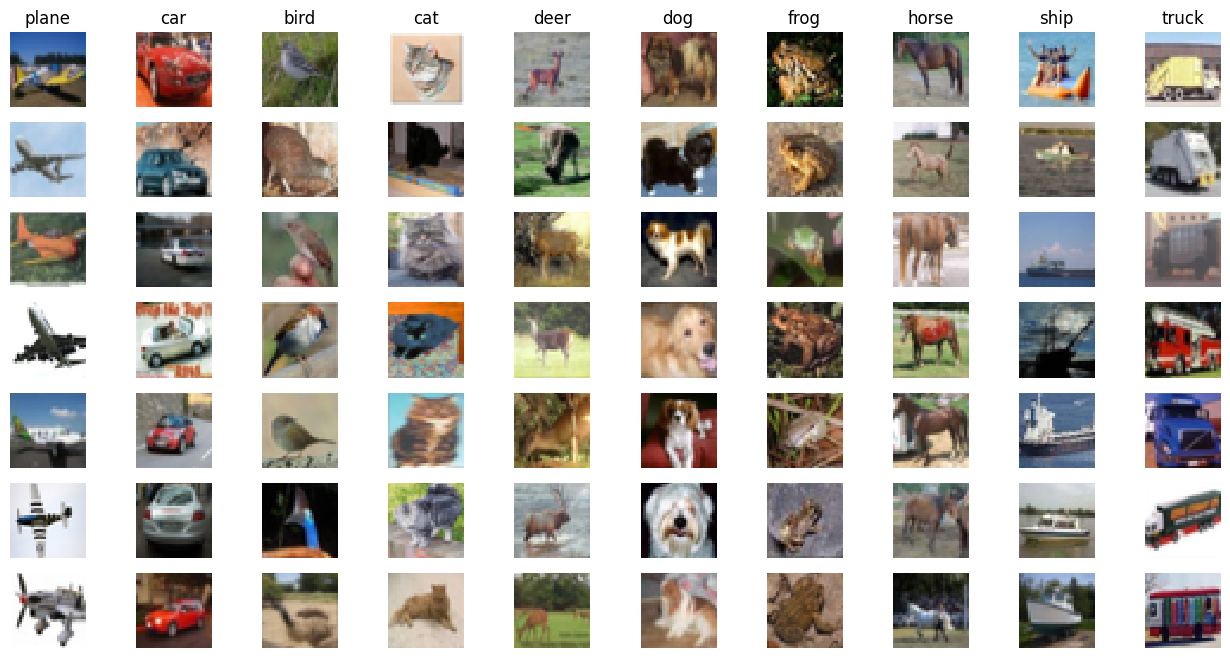

In [20]:
# Перед началом работы полезно посмотреть на данные.
# Отобразим пример из каждого класса.
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = len(classes)
samples_per_class = 7
for y, cls in enumerate(classes):
    idxs = np.flatnonzero(y_train == y)
    idxs = np.random.choice(idxs, samples_per_class, replace=False)
    for i, idx in enumerate(idxs):
        plt_idx = i * num_classes + y + 1
        plt.subplot(samples_per_class, num_classes, plt_idx)
        plt.imshow(X_train[idx].astype('uint8'))
        plt.axis('off')
        if i == 0:
            plt.title(cls)
plt.show()

In [21]:
# Для удобства преобразуем двумерные изображения в одномерные вектора fp64
X_train = np.reshape(X_train, (X_train.shape[0], -1)).astype(np.float64)
X_test = np.reshape(X_test, (X_test.shape[0], -1)).astype(np.float64)
y_train = y_train.flatten()
y_test = y_test.flatten()
# Проверим размер полученных данных
print('Training data shape: ', X_train.shape)
print('Test data shape: ', X_test.shape)
print('Training label shape: ', y_train.shape)
print('Test label shape: ', y_test.shape)

Training data shape:  (50000, 3072)
Test data shape:  (10000, 3072)
Training label shape:  (50000,)
Test label shape:  (10000,)


[130.71074 136.05614 132.5538  130.14036 135.44238 131.85358 131.05044
 136.24616 132.58144 131.56886]


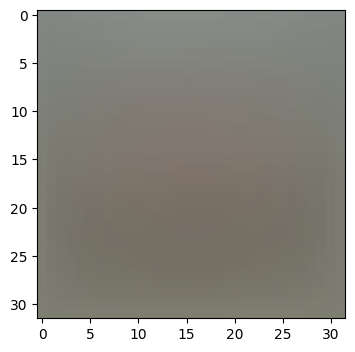

In [22]:
# Нормализуем значения яркости пикселей 
mean_image = np.mean(X_train, axis=0)
print(mean_image[:10]) 

# визуализируем среднюю яркость
plt.figure(figsize=(4,4))
plt.imshow(mean_image.reshape((32,32,3)).astype('uint8')) 
plt.show()

In [23]:
# Вычтем средние значения яркости
X_train -= mean_image
X_test -= mean_image

# Добавим к вектору исходных данных фиктивный признак с постоянным значением 1.
# Этот трюк позволит избежать лишних вычислений: x @ W + b  => x' @ W'
X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])

print(X_train.shape, X_test.shape)

(50000, 3073) (10000, 3073)


# Стохастический градиентный спуск

In [24]:
# Используем линейную модель keras
softmax_cls = tf.keras.Sequential([
    tf.keras.layers.Dense(num_classes, activation='softmax', input_shape=(3073,))
]) 

/home/andrej/miniconda3/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1772469105.511077  475938 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1772469105.521144  475938 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [26]:
%time
optimizer = tf.keras.optimizers.SGD(learning_rate=1e-4, momentum=0.9)
softmax_cls.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
loss_hist = softmax_cls.fit(X_train[:1000], y_train[:1000], epochs=10, batch_size=200)


CPU times: user 1 μs, sys: 1e+03 ns, total: 2 μs
Wall time: 5.01 μs
Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1310 - loss: 105.3541  
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2640 - loss: 75.9574 
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3460 - loss: 55.0981 
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3950 - loss: 41.4048 
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4370 - loss: 34.6522 
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5110 - loss: 25.5249 
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5300 - loss: 21.3623 
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5630 - loss: 20.6680 
Epoch 9/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5770 - loss: 18.9971 
Epoch 10/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5930 - loss: 17.2513 


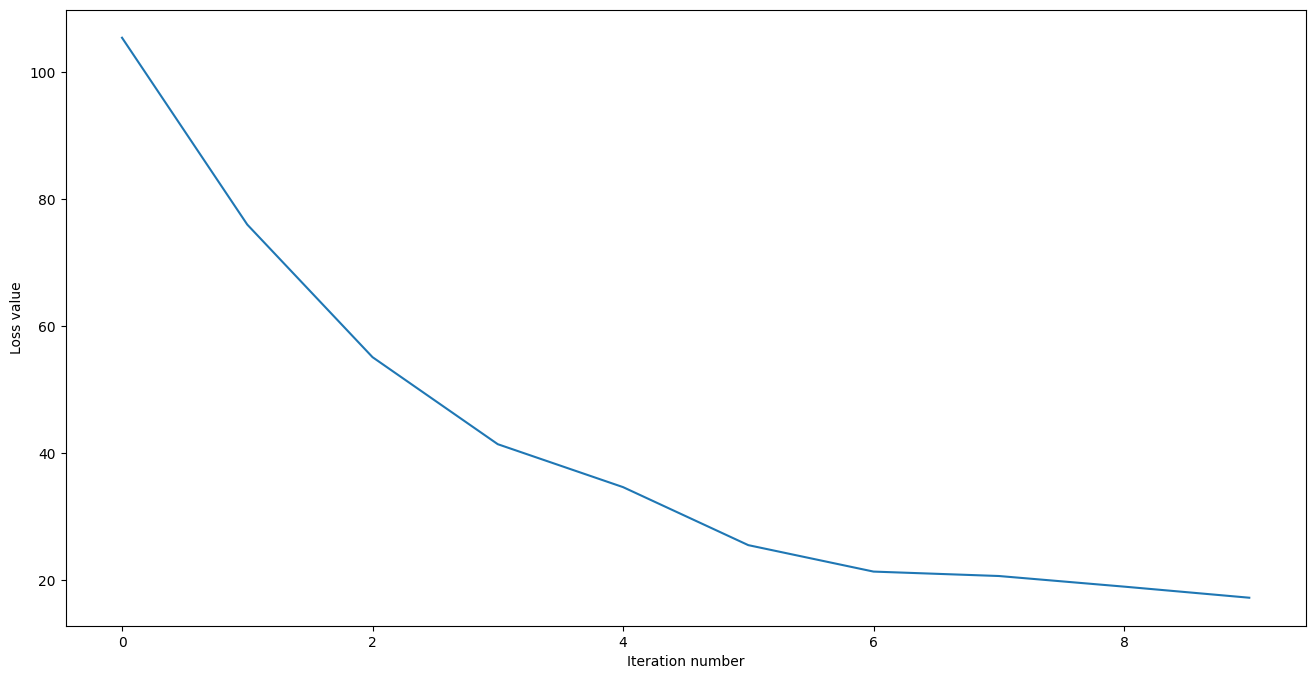

In [28]:
# Построим график зависимости loss от количества итераций
plt.plot(loss_hist.history['loss'])
plt.xlabel('Iteration number')
plt.ylabel('Loss value')
plt.show()

In [ ]:
# оцените точность предсказания на выборках train и val
y_train_pred = np.argmax(softmax_cls.predict(X_train), axis=1)
print('training accuracy: %f' % (np.mean(y_train == y_train_pred) ))
y_test_pred = np.argmax(softmax_cls.predict(X_test), axis=1)
print('validation accuracy: %f' % (np.mean(y_test == y_test_pred) ))

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 361us/step
training accuracy: 0.268060
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 359us/step
validation accuracy: 0.253700


# Поиск лучших гиперпараметров

In [ ]:
# Используйте валидационную выборку для выбора лучших гиперпараметров 
# (learning rate and regularization strength)
# Добейтесь точности не меньше 0.38 на выборке test.
# Используйте словарь results в котором 
# ключи - кортеж  (learning_rate, regularization_strength)
# значения - (training_accuracy, validation_accuracy)
# Точность вычисляется как отношение числа верно предсказанных классов 
# к объему выборки
results = {}
best_val = -1   
best_softmax = None # Лучший экземпляр Softmax classifier 

################################################################################
# TODO:                                                                        #
# Напишите код, позволяющий найти лучшее значение гиперпараметров на val       #
# выборке. Для каждой комбинации гиперпараметров обучите классификатор         #
# на train выборке, вычислите точность на выборках train, val и сохраните      #
# результат в словарь results. Лучшее значение точности сохраните в best_val   #
# лучший классификатор - в best_softmax                                        #
#                                                                              #
################################################################################

# Пример списка допустимых значений. Можете изменить на свое усмотрение.
learning_rates = [1e-7, 5e-5]
regularization_strengths = [1e-1, 1, 10]

# *****START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****


# *****END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****
    
# Вывод результатов.
for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr, reg)]
    print('lr %e reg %e train accuracy: %f val accuracy: %f' % (
                lr, reg, train_accuracy, val_accuracy))
    
print('best validation accuracy achieved during cross-validation: %f' % best_val)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 356us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 358us/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 345us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 356us/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 343us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 355us/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 334us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 351us/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 349us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 359us/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 343us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 354us/step
lr 1.000000e-07 reg 1.000000e-01 train accuracy: 0.274020 val accuracy: 0.261400
lr 1.000000e-07 reg 1.000000e+00 train accuracy: 0.278680 val accuracy: 0.264700
lr 1.000000e-07 reg 1.000000e+01 train accuracy: 0.281220 val accuracy: 0.265500
lr 5.000000e-05 reg 1.000000e-01 train accuracy: 0.259780 val accuracy: 0.236900
lr 5.000000e-05 reg 1.000000e+00 train accuracy: 0.263840 val accuracy: 0.241100
lr 5.000000e-05 reg 1.000000e+01 train accuracy: 0.264440 val accur

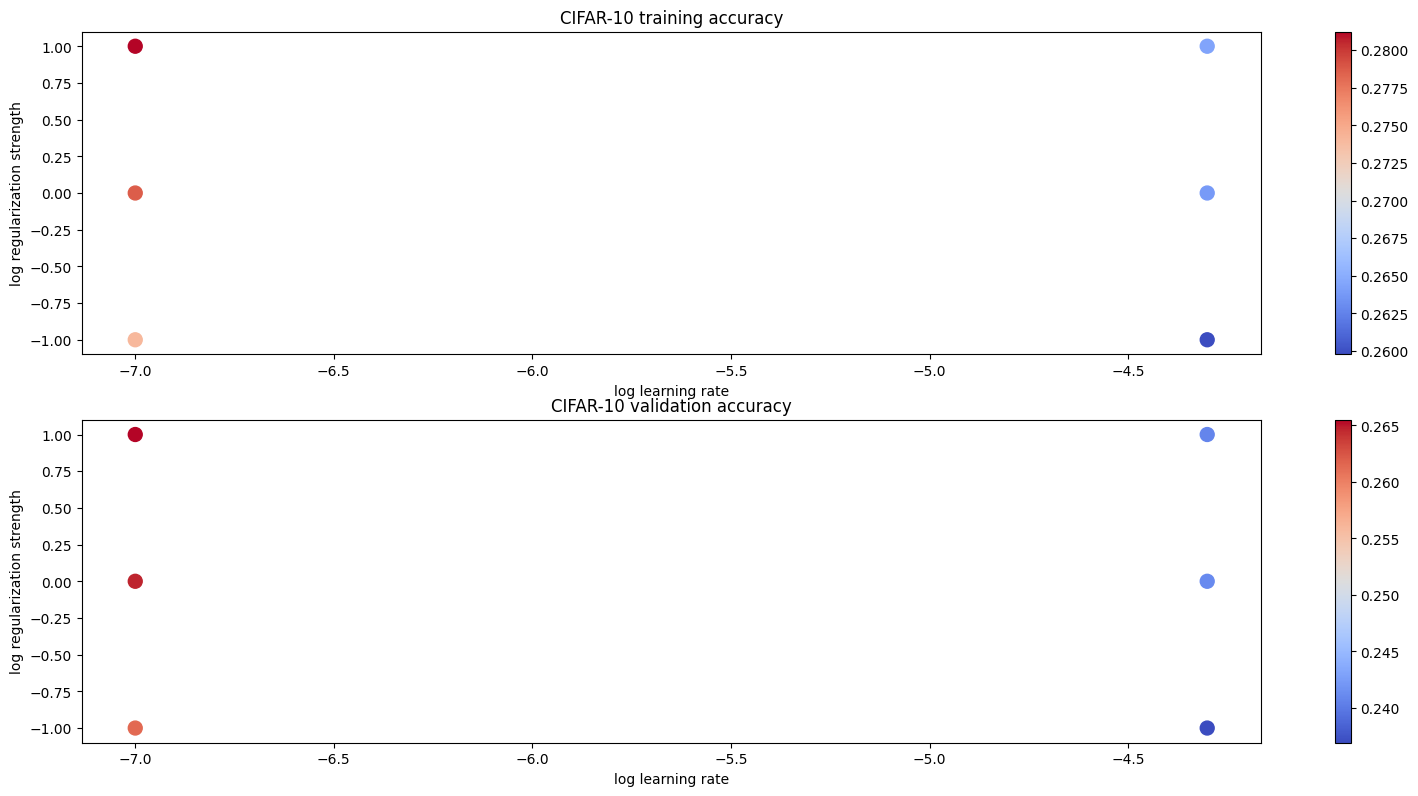

In [ ]:
# Визуализируем результаты кросс-валидации
import math

x_scatter = [math.log10(x[0]) for x in results]
y_scatter = [math.log10(x[1]) for x in results]

# график accuracy на обучении
marker_size = 100
colors = [results[x][0] for x in results]
plt.subplot(2, 1, 1)
plt.tight_layout(pad=3)
plt.scatter(x_scatter, y_scatter, marker_size, c=colors, cmap=plt.cm.coolwarm)
plt.colorbar()
plt.xlabel('log learning rate')
plt.ylabel('log regularization strength')
plt.title('CIFAR-10 training accuracy')

# график accuracy на валидации
colors = [results[x][1] for x in results] # default size of markers is 20
plt.subplot(2, 1, 2)
plt.scatter(x_scatter, y_scatter, marker_size, c=colors, cmap=plt.cm.coolwarm)
plt.colorbar()
plt.xlabel('log learning rate')
plt.ylabel('log regularization strength')
plt.title('CIFAR-10 validation accuracy')
plt.show()

# Точность на test выборке


In [36]:
y_test_pred = np.argmax(best_softmax.predict(X_test), axis=1)
test_accuracy = np.mean(y_test == y_test_pred)
print('softmax on raw pixels final test set accuracy: %f' % (test_accuracy, ))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 394us/step
softmax on raw pixels final test set accuracy: 0.240800


In [38]:
best_softmax.save('softmax_weights.keras')

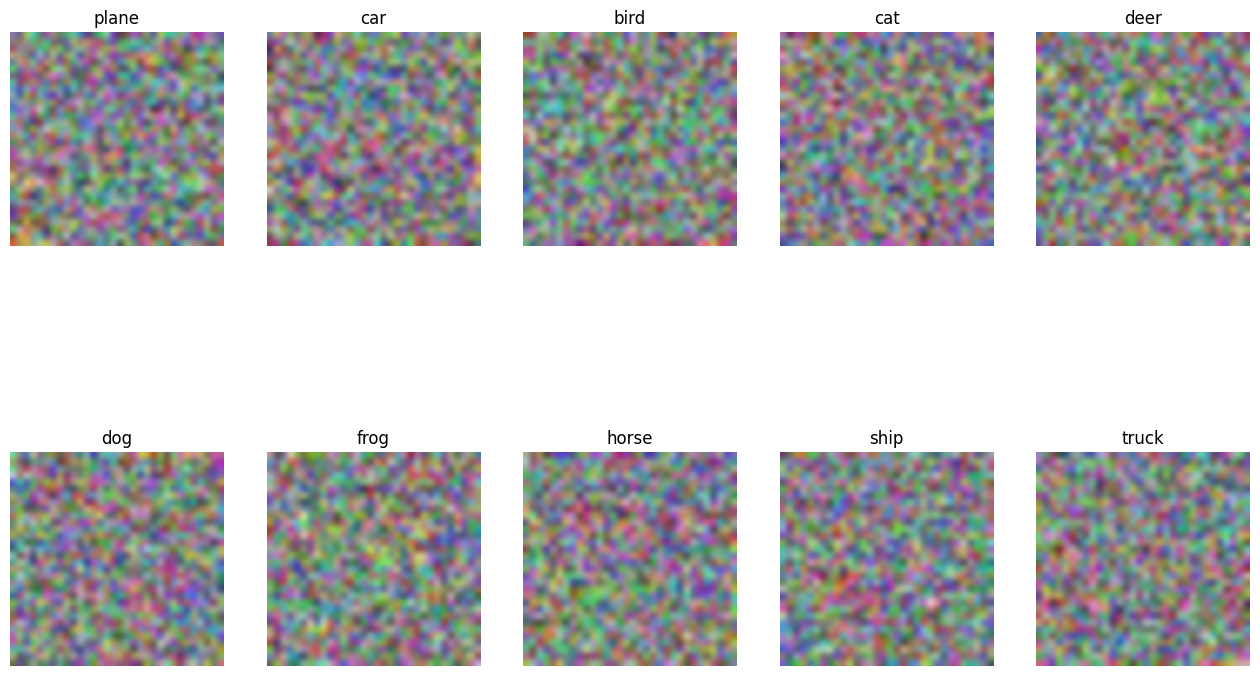

In [39]:
# Визуализируем веса W для каждого класса
w = best_softmax.get_weights()[0][:-1,:] # отбросим фиктивное измерение bias
w = w.reshape(32, 32, 3, 10)

w_min, w_max = np.min(w), np.max(w)

classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
plt.figure(figsize=(16, 10))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    
    # Масштабируем веса в значения от 0 до 255 для визуализации
    wimg = 255.0 * (w[:, :, :, i].squeeze() - w_min) / (w_max - w_min)
    plt.imshow(wimg.astype('uint8'), interpolation='quadric')
    plt.axis('off')
    plt.title(classes[i])